# Chapter 03-02 · Why two samples never agree

**Label:** Core  |  **Time:** ~50 minutes  |  **Difficulty:** moderate - the simulation is easy, the
implications take a while to sink in

**Prerequisites:** 03-01. You should be able to compute a mean and a standard deviation and say what
each one minimises.

**Position in the learning path:** module 03, chapter 2 of 8. Before: **03-01**. After: **03-03**,
which turns everything here into an error bar you can put on a number.

---

## Why this matters

In 03-01 you watched seven mornings and computed that the 14 bus is **6 minutes late on average**.

Here is the question that chapter could not answer: *if you had watched a different seven mornings,
what would you have got?*

Everything downstream depends on the answer. A model scores 0.83 on a test set - would it have scored
0.83 on a different test set? Version B beat version A by 4% - would it have, on a different week?
Without a sense of how much a number moves when nothing real changes, you cannot tell a finding from
a fluctuation, and you will spend your career explaining noise.

This chapter builds that sense by doing something real life never permits: **inventing a population,
so we know the true answer, and then watching how badly samples of it miss.**

## What you will be able to do

- Explain the difference between a population and a sample, and between a standard deviation and a
  standard error
- Predict how much a sample mean moves, from the formula, and confirm it by simulation
- State how much data it takes to halve your uncertainty
- Say why "30 is enough" is folklore, and what it depends on
- Show that two identical things can differ by 13% and mean nothing

## Warm-up: retrieve, do not reread

1. What does the mean minimise, and what does the median minimise?
2. `np.var` and `pandas.var` disagree on the same data. Why?
3. Why does dividing the sum of squares by `n` underestimate the variance?
4. What is the breakdown point of the mean?

<br>

*Answers: (1) total squared error; total absolute error. (2) `ddof` - numpy defaults to 0, pandas to
1. (3) the deviations are measured from your own sample's mean, which sits closer to your data than
the true mean does, so the squares come out too small - by exactly (n-1)/n. (4) zero - a single value
can move it arbitrarily far.*

## A population we are allowed to see

Here is the move that makes this chapter work. We invent the full population of bus mornings - every
morning the 14 bus will ever run - and we know its mean exactly, because we chose it.

**In real work you never have this.** You have one sample and no way to check it against the truth.
That is precisely why it is worth spending fifty minutes in a world where you can check, building
intuitions you will then have to trust when you cannot.

THE POPULATION (which in real life you never get to see)
  mean   : 6.0064 minutes
  median : 5.0432 minutes
  sd     : 4.2460 minutes


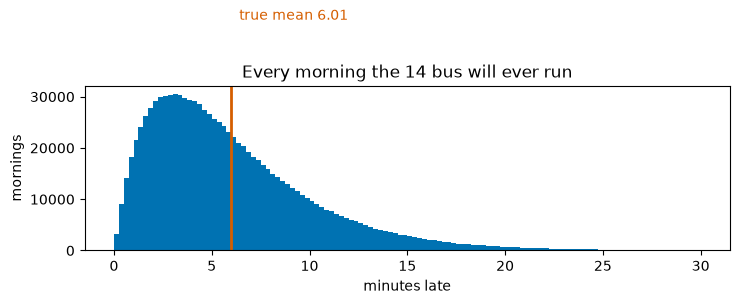

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SYNTHETIC POPULATION. A million mornings, right-skewed the way waiting times are:
# mostly a few minutes late, occasionally much worse.
pop_rng = np.random.default_rng(11)
population = pop_rng.gamma(2.0, 3.0, 1_000_000)

print("THE POPULATION (which in real life you never get to see)")
print("  mean   : %.4f minutes" % population.mean())
print("  median : %.4f minutes" % np.median(population))
print("  sd     : %.4f minutes" % population.std())

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(population, bins=120, range=(0, 30), color="#0072B2")
ax.axvline(population.mean(), color="#D55E00", linewidth=2)
ax.text(population.mean() + 0.4, 45000, "true mean 6.01", color="#D55E00")
ax.set_xlabel("minutes late")
ax.set_ylabel("mornings")
ax.set_title("Every morning the 14 bus will ever run")
plt.tight_layout()
plt.show()

The true mean is **6.01 minutes** - which is almost exactly the 6.0 that 03-01's seven mornings
produced. That chapter got a good answer.

### Predict before running

The next cell watches five separate weeks - five independent samples of seven mornings each - and
reports the mean of each.

Before running it, write down:

1. How far apart do you expect the highest and lowest of those five weekly means to be? Guess a
   number of minutes.
2. Would you be surprised by a week averaging 4 minutes? By one averaging 9?

In [2]:
week_rng = np.random.default_rng(1)

for week in range(1, 6):
    sample = population[week_rng.integers(0, len(population), 7)]
    print("week %d:  %s   mean %5.2f" % (week, np.sort(sample).round(1), sample.mean()))

week 1:  [ 0.7  1.2  2.2  3.4  4.2  7.1 14.4]   mean  4.75
week 2:  [ 1.5  7.6  9.8 11.  11.1 11.8 15.4]   mean  9.74
week 3:  [ 0.6  0.8  1.7  2.5  4.3  9.3 11.6]   mean  4.39
week 4:  [ 2.6  6.9  7.3  9.8 10.8 12.7 13.1]   mean  9.03
week 5:  [ 2.4  3.4  5.   8.4  9.5 13.5 14. ]   mean  8.03


## The sampling distribution

Five weeks is not enough to see the pattern. Take a hundred thousand of them.

Each sample of seven gives one mean. The distribution of *those means* is called the **sampling
distribution of the mean**, and it is the central object of this chapter. Notice that it is a
distribution of a *statistic*, not of the data - one point per sample, not one point per morning.

In [3]:
sim_rng = np.random.default_rng(1)


def sample_means(n, repeats=100_000):
    draws = population[sim_rng.integers(0, len(population), (repeats, n))]
    return draws.mean(axis=1)


means_of_7 = sample_means(7)

print("across 100,000 weeks of seven mornings:")
print("  average of the sample means : %.4f   (the true mean is %.4f)"
      % (means_of_7.mean(), population.mean()))
print("  spread of the sample means  : %.4f" % means_of_7.std())
print()
low, high = np.quantile(means_of_7, [0.025, 0.975])
print("  95%% of weeks give a mean between %.2f and %.2f minutes" % (low, high))
print("  share of weeks below 4 or above 8 minutes: %.3f" % ((means_of_7 < 4) | (means_of_7 > 8)).mean())

across 100,000 weeks of seven mornings:
  average of the sample means : 6.0031   (the true mean is 6.0064)
  spread of the sample means  : 1.6138

  95% of weeks give a mean between 3.27 and 9.57 minutes
  share of weeks below 4 or above 8 minutes: 0.206


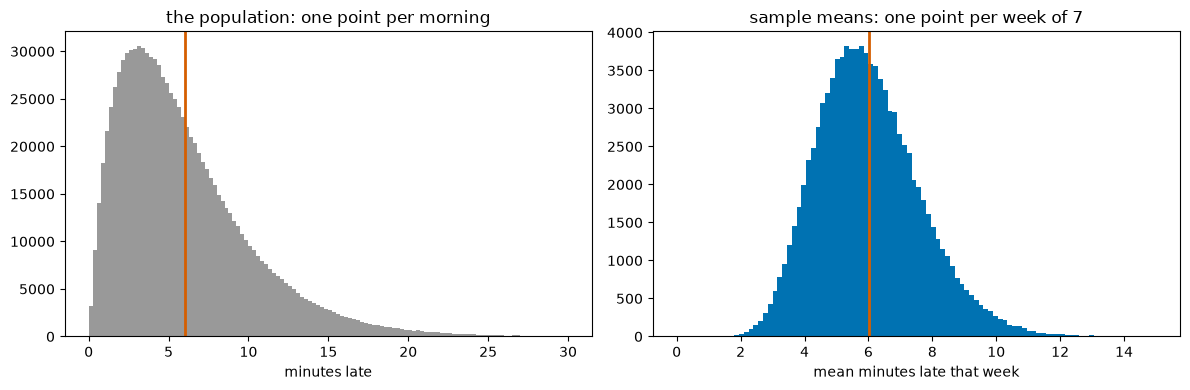

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

left.hist(population, bins=120, range=(0, 30), color="#999999")
left.axvline(population.mean(), color="#D55E00", linewidth=2)
left.set_title("the population: one point per morning")
left.set_xlabel("minutes late")

right.hist(means_of_7, bins=100, range=(0, 15), color="#0072B2")
right.axvline(population.mean(), color="#D55E00", linewidth=2)
right.set_title("sample means: one point per week of 7")
right.set_xlabel("mean minutes late that week")

plt.tight_layout()
plt.show()

### What that says about 03-01's answer

The sample means **centre on the truth** - 6.0031 against 6.0064 - so the procedure is not biased. On
average, seven mornings gives the right answer.

But **95% of weeks land between 3.27 and 9.57 minutes**, and one week in five falls outside 4 to 8.

So the honest reading of 03-01 is not "the bus is 6 minutes late". It is **"the bus is somewhere
around 6 minutes late, and seven mornings cannot pin it down closer than about plus or minus 3"**.
The number 6.0 was correct and its precision was imaginary.

Notice also the shape. The population is strongly right-skewed; the sampling distribution is much
more symmetric, and much narrower. Both of those are general, and the next two sections say how much.

## The standard error, and where it comes from

The spread of the sampling distribution has its own name - the **standard error** - to keep it
distinct from the spread of the data. It has a formula:

> **standard error of the mean = (standard deviation of the population) / sqrt(n)**

Nothing here derives it. Instead, check it.

In [5]:
rows = []
for n in [7, 28, 112, 448]:
    observed = sample_means(n, 40_000).std()
    rows.append({
        "sample size n": n,
        "observed spread of means": round(float(observed), 4),
        "sd / sqrt(n)": round(float(population.std() / np.sqrt(n)), 4),
    })

table = pd.DataFrame(rows)
table["relative to n = 7"] = (table["observed spread of means"]
                              / table["observed spread of means"].iloc[0]).round(3)
print(table.to_string(index=False))

 sample size n  observed spread of means  sd / sqrt(n)  relative to n = 7
             7                    1.6053        1.6048              1.000
            28                    0.8020        0.8024              0.500
           112                    0.3993        0.4012              0.249
           448                    0.1993        0.2006              0.124


### The most useful consequence in the whole module

The observed spreads match `sd / sqrt(n)` to within a few parts in a thousand, and the last column
is the punchline:
each time `n` **quadruples**, the standard error **halves**. 1.000, 0.500, 0.249, 0.124.

> **To halve your uncertainty, you need four times as much data. To reduce it tenfold, a hundred
> times as much.**

This single fact governs an enormous amount of practical work:

- Seven mornings gives about plus or minus 3 minutes. Getting to plus or minus 0.3 needs a hundred
  times as many - roughly 700 mornings, or nearly three years of commuting.
- A model evaluated on 100 test rows has roughly three times the uncertainty of one evaluated on
  900 - which is why test-set size matters as much as training-set size, and why 04-03 spends a
  chapter on it.
- The returns to collecting more data diminish, and they diminish in a completely predictable way.
  When someone proposes doubling a dataset, the honest expectation is a 29% reduction in uncertainty,
  not half.

## Failure lab: the standard deviation and the standard error are different numbers

This is the most common confusion in applied statistics, and it is worth meeting as a table rather
than as a definition.

**One shrinks with more data. The other does not.**

In [6]:
rows = []
for n in [7, 28, 112, 448]:
    draws = population[sim_rng.integers(0, len(population), (20_000, n))]
    rows.append({
        "sample size n": n,
        "average sample sd": round(float(draws.std(axis=1, ddof=1).mean()), 4),
        "spread of the means (se)": round(float(draws.mean(axis=1).std()), 4),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\nthe population sd is %.4f and never changes" % population.std())

 sample size n  average sample sd  spread of the means (se)
             7             3.9087                    1.5950
            28             4.1576                    0.7982
           112             4.2203                    0.3990
           448             4.2388                    0.1999

the population sd is 4.2460 and never changes


### Diagnosis

The sample standard deviation climbs from 3.91 to **4.24** and stops there - it is estimating a
fixed property of the population, and more data makes that estimate *better*, not *smaller*. The
standard error falls from 1.60 to 0.20 across the same range, and keeps falling.

They answer different questions, and reporting the wrong one is a real error with a direction:

| Number | Question it answers | Use it when |
|---|---|---|
| **Standard deviation** | How much do individual mornings vary? | Describing the data, sizing risk for one case, deciding whether anyone will notice a difference |
| **Standard error** | How much would my *estimate* move if I collected another sample? | Putting an uncertainty on a summary, comparing two groups, deciding whether a difference is real |

"6 minutes, plus or minus 4.25" describes how much mornings differ from each other. "6 minutes, plus
or minus 1.6" describes how much your knowledge of the average is worth. Quoting the first as though
it were the second makes your estimate look far less certain than it is; quoting the second as though
it were the first makes individual mornings look far more predictable than they are - which is the
02-07 bar-chart error in a new costume.

**One honest footnote.** The average sample standard deviation at n = 7 is **3.91**, noticeably below
the population's 4.25, even though `ddof=1` was used. The `n - 1` correction from 03-01 makes the
*variance* unbiased, and taking a square root does not preserve that - the standard deviation stays
slightly too small on small samples. It is a small effect that disappears with n, and it is worth
knowing that the correction you learned last chapter fixes one thing and not quite the other.

## Why the sampling distribution looks normal

The population is visibly skewed. The sampling distribution of the mean was not. That is the central
limit theorem, and it is the reason so much of statistics is written in terms of normal
distributions.

The usual statement of it is a limit as `n` grows, which is not directly useful - what you need to
know is **how fast**, for *your* data. So measure the skewness of the sampling distribution as `n`
increases.

In [7]:
rows = []
for n in [1, 2, 5, 30, 100]:
    means = sample_means(n, 60_000)
    standardised = (means - means.mean()) / means.std()
    rows.append({"sample size n": n,
                 "skewness of the sampling distribution": round(float((standardised ** 3).mean()), 3)})
print(pd.DataFrame(rows).to_string(index=False))
print("\n0 would be perfectly symmetric. n = 1 is just the population itself.")

 sample size n  skewness of the sampling distribution
             1                                  1.399
             2                                  0.991
             5                                  0.625
            30                                  0.250
           100                                  0.146

0 would be perfectly symmetric. n = 1 is just the population itself.


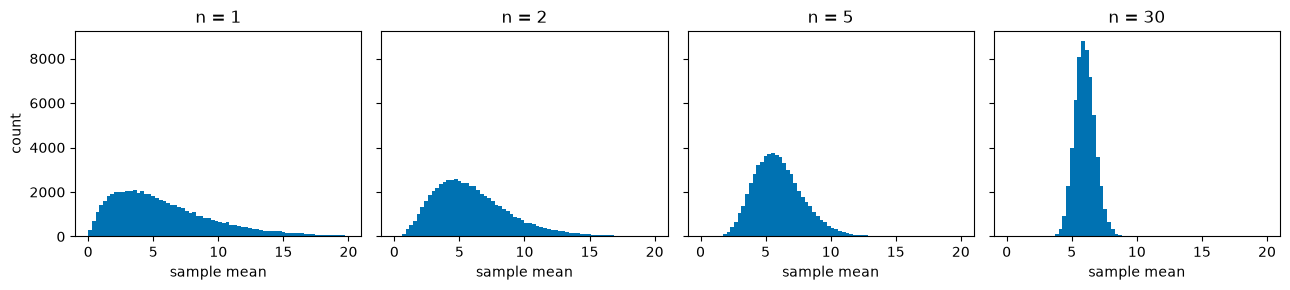

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
for ax, n in zip(axes, [1, 2, 5, 30]):
    means = sample_means(n, 60_000)
    ax.hist(means, bins=70, range=(0, 20), color="#0072B2")
    ax.set_title("n = %d" % n)
    ax.set_xlabel("sample mean")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

### "Thirty is enough" is folklore

Skewness falls from **1.399** at n = 1 to **0.250** at n = 30 and **0.146** at n = 100. It does not
reach zero; it approaches it, roughly in proportion to `1 / sqrt(n)`.

So the honest version of the rule is:

- **How large `n` needs to be depends on how skewed the population is.** For this moderately skewed
  population, 30 leaves a visible tail. For a symmetric population, 5 would be plenty. For something
  with genuinely heavy tails - income, insurance claims, file sizes - even 1,000 can be inadequate,
  and for some distributions the theorem does not apply at all.
- **You can check rather than assume.** You cannot resample a population you do not have, but you can
  resample your own data, which is exactly what 03-03 does with the bootstrap.

The reason this matters: every classical confidence interval and every `p`-value you will meet
assumes the sampling distribution is normal. When it is not, those tools do not warn you - they
return a number with the wrong width.

## Failure lab 2: two identical things, one clear winner

The transport authority tests a new timetable. Route A keeps the old one, route B gets the new one,
100 mornings each. Then they compare.

**Both arms below are drawn from exactly the same population.** The new timetable does nothing at
all - the two arms are identical by construction.

In [9]:
trial_rng = np.random.default_rng(23)
arm_a = population[trial_rng.integers(0, len(population), 100)]
arm_b = population[trial_rng.integers(0, len(population), 100)]

print("arm A (old timetable) : mean %.3f minutes late over 100 mornings" % arm_a.mean())
print("arm B (new timetable) : mean %.3f minutes late over 100 mornings" % arm_b.mean())
print()
print("B looks %.1f%% better." % (100 * (arm_a.mean() - arm_b.mean()) / arm_a.mean()))
print("The true difference between the two is exactly zero.")

arm A (old timetable) : mean 6.851 minutes late over 100 mornings
arm B (new timetable) : mean 5.941 minutes late over 100 mornings

B looks 13.3% better.
The true difference between the two is exactly zero.


### Predict before running

That result is a 13.3% improvement, from a change that does nothing. It would survive a meeting.

Before running the next cell: if you repeated this trial 40,000 times, always with two identical
arms, what fraction of the time would you see an apparent difference of **more than 5%**? Write a
number down.

In [10]:
ab_rng = np.random.default_rng(7)

rows = []
for n in [50, 100, 400]:
    a = population[ab_rng.integers(0, len(population), (40_000, n))].mean(axis=1)
    b = population[ab_rng.integers(0, len(population), (40_000, n))].mean(axis=1)
    relative = 100 * np.abs(b - a) / a
    rows.append({
        "mornings per arm": n,
        "typical apparent difference": "%.2f%%" % np.median(relative),
        "share above 5%": round(float((relative > 5).mean()), 3),
        "share above 10%": round(float((relative > 10).mean()), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))
pair_rng = np.random.default_rng(31)
a100 = population[pair_rng.integers(0, len(population), (40_000, 100))].mean(axis=1)
b100 = population[pair_rng.integers(0, len(population), (40_000, 100))].mean(axis=1)
print()
print("spread of the difference at n = 100, observed  : %.4f" % (b100 - a100).std())
print("                             se x sqrt(2)      : %.4f"
      % (population.std() / np.sqrt(100) * np.sqrt(2)))

 mornings per arm typical apparent difference  share above 5%  share above 10%
               50                       9.51%           0.724            0.478
              100                       6.76%           0.616            0.316
              400                       3.39%           0.318            0.047



spread of the difference at n = 100, observed  : 0.6030
                             se x sqrt(2)      : 0.6005


### Diagnosis

With 100 mornings per arm and **no real effect whatsoever**, the typical apparent difference is
**6.76%**, and **61.6% of trials produce a gap larger than 5%**. Nearly a third exceed 10%.

Two things follow, and they are the reason this chapter exists.

**First: an observed difference is not evidence of a difference.** Before believing any comparison,
you need to know how large a gap the noise produces on its own - and this simulation is one way to
find out. It is the same argument as 02-07's forty noise columns, now applied to a comparison rather
than a search, and both reduce to the same question: *what does nothing look like?*

**Second: the spread of a difference is larger than the spread of either side.** Comparing two
estimates involves the uncertainty of both, and the two contributions combine as `se x sqrt(2)` -
0.6030 observed against 0.6005 predicted. This is the property 03-01 mentioned as a reason to prefer
variance over mean absolute deviation: **variances of independent quantities add**. Here is that
abstract fact producing a concrete number.

A practical corollary: a comparison needs roughly **twice** the data of a single estimate to reach
the same precision, and each arm needs the full amount. "We split our 100 users into two groups of
50" is not a smaller version of the same experiment; it is a substantially worse one.

## Which summary is more precise? It depends on the tails

03-01 said the median is robust and the mean is not, and left it there. Robustness has a second
dimension worth knowing about: **how much a summary moves from sample to sample**.

There is a standard error of the median just as there is of the mean, and which of the two is
smaller is not a fixed fact.

In [11]:
def compare_estimators(pop, label):
    rows = []
    rng = np.random.default_rng(2)
    for n in [7, 31, 101]:
        draws = pop[rng.integers(0, len(pop), (40_000, n))]
        se_mean = draws.mean(axis=1).std()
        se_median = np.median(draws, axis=1).std()
        rows.append({"n": n,
                     "se of the mean": round(float(se_mean), 4),
                     "se of the median": round(float(se_median), 4),
                     "median / mean": round(float(se_median / se_mean), 3)})
    print(label)
    print(pd.DataFrame(rows).to_string(index=False))


compare_estimators(population, "MODERATELY SKEWED POPULATION (the one we have been using)")

MODERATELY SKEWED POPULATION (the one we have been using)
  n  se of the mean  se of the median  median / mean
  7          1.6061            1.7892          1.114
 31          0.7675            0.8614          1.122
101          0.4232            0.4777          1.129


In [12]:
# The same bus route, but 3% of mornings involve an actual breakdown.
cont_rng = np.random.default_rng(5)
size = 1_000_000
ordinary = cont_rng.gamma(2.0, 3.0, size)
breakdown = cont_rng.random(size) < 0.03
contaminated = np.where(breakdown, ordinary + cont_rng.gamma(2.0, 60.0, size), ordinary)

print("CONTAMINATED POPULATION")
print("  mean %.3f   median %.3f   sd %.3f" % (contaminated.mean(), np.median(contaminated),
                                               contaminated.std()))
print()
compare_estimators(contaminated, "3% OF MORNINGS ARE BREAKDOWNS")

CONTAMINATED POPULATION
  mean 9.588   median 5.194   sd 25.520



3% OF MORNINGS ARE BREAKDOWNS
  n  se of the mean  se of the median  median / mean
  7          9.6497            1.9594          0.203
 31          4.6238            0.9101          0.197
101          2.5327            0.5014          0.198


### The result reverses

On the moderately skewed population the median is **about 13% less precise** than the mean - you pay
for robustness. On the contaminated population the median is **five times more precise** - the mean's
standard error at n = 101 is 2.53 minutes against the median's 0.50.

Both are correct, and the lesson is the shape of the dependence:

- With light tails, the mean uses every value's magnitude and that information is worth having, so it
  wins.
- With heavy tails, the mean's estimate is dominated by whichever extreme values happened to land in
  your sample, so it swings wildly from sample to sample. The median ignores their magnitudes and is
  barely affected.

**So "the median is robust" and "the median is imprecise" are both true, on different data.** There
is no summary that is best everywhere, and the property that decides it - how heavy the tails are -
is something you have to look at, which is what module 02 was for.

## Common misconceptions

**"A bigger sample makes the data less variable."**
It makes your *estimate* less variable. The data varies exactly as much as it always did - the sample
standard deviation stayed near 4.25 at every size above.

**"My sample mean is 6.0, so the population mean is about 6.0."**
It is *around* 6.0, and how far around depends entirely on `n`. At n = 7 that is plus or minus 3
minutes, which is a completely different claim from the same number at n = 700.

**"With 30 observations the central limit theorem applies."**
There is no threshold. The approximation improves gradually and how fast depends on the population's
skew - 0.250 skewness at n = 30 here, and worse for heavier tails.

**"B beat A, so B is better."**
Two identical arms differed by more than 5% in 61.6% of trials at 100 per arm. An observed difference
is a starting point, not a result.

**"We doubled the data, so we halved the error."**
Doubling reduces the standard error by a factor of `1/sqrt(2)` - about 29%. Halving it takes four
times the data.

**"The sampling distribution is a property of my data."**
It is a property of the population *and* your sample size *and* the statistic you compute. The median
and the mean have different sampling distributions on the same data, as the last section showed.

## Exercises

Solutions: `solutions/03_math_foundations/03-02_sampling_solutions.ipynb`.

### Quick understanding

**E1.** In one sentence each: what does the standard deviation measure, and what does the standard
error measure?

**E2.** You quadruple your sample. What happens to the standard error, and what happens to the sample
standard deviation?

**E3.** Why is the sampling distribution of the mean narrower than the population, and why is it more
symmetric?

### Hand calculation

**E4.** A population has sd 20. What sample size do you need for a standard error of 2? Of 1? Of 0.5?
Say what the pattern in your three answers is called.

**E5.** Survey A samples 400 people, survey B samples 1,600 from the same population. B's confidence
interval is how many times narrower? A colleague says "B is four times better". What is wrong with
that?

### Coding

**E6.** Write `standard_error(pop, n, repeats)` that estimates the standard error of the mean by
simulation, and compare it with `pop.std() / np.sqrt(n)` for n from 2 to 200. Plot both against n.

**E7.** Repeat the two-identical-arms experiment, but compare **medians** rather than means, on the
contaminated population. Does the false-winner rate go up or down? Explain the result using the last
section of the chapter.

**E8.** The standard error formula uses the *population* standard deviation, which you never have.
Repeat the n = 7 simulation but estimate the standard error from each sample alone, as
`sample.std(ddof=1) / np.sqrt(7)`. How close is the average of those estimates to the truth, and in
which direction is it wrong?

### Interpretation

**E9.** A dashboard shows weekly conversion rate, computed from about 200 sessions per week, and it
moves between 3.1% and 4.4% over eight weeks. Your manager asks which week's change to investigate.
Answer, using a number.

**E10.** A study of 12 patients reports a mean improvement of 8 points with a standard deviation of
14. What is the standard error, and what would you say to someone who reports the result as "an
8-point improvement"?

### Debugging

**E11.** An analyst reports "mean session length 4.2 minutes, standard error 3.9 minutes" for 2,000
sessions, and concludes the estimate is unreliable. Two things are wrong. Identify both, and say what
the standard error probably is.

### Exam and interview reasoning

**E12.** "How would you decide whether a 3% improvement in an A/B test is real?" Answer in five
sentences without using the word significance.

### Transfer to a different situation

**E13.** A model scores 0.83 accuracy on a test set of 200 rows. Using this chapter's ideas, work out
roughly how much that number would move on a different test set of the same size, and say what test
set size you would want to distinguish a model scoring 0.83 from one scoring 0.85. (Hint: accuracy is
a mean of zeros and ones, so its sd is `sqrt(p * (1 - p))`.)

### Explain it to someone non-technical

**E14.** Explain to the transport committee why the trial showing "13% improvement" from the new
timetable does not show that the timetable helped. Under 100 words, no jargon.

### Optional challenge

**E15.** The standard error of the mean falls as `1/sqrt(n)`. Find out, by simulation, how the
standard error of the **maximum** behaves as `n` grows on this population, and on a normal
population. Does it shrink at all? What does your answer say about estimating "the worst case" from a
sample?

In [13]:
# Your workspace. In memory: population, contaminated, sample_means,
# compare_estimators, means_of_7, arm_a, arm_b.

## Mastery check

- [ ] Explain population, sample, sampling distribution, and standard error without confusing any two
- [ ] Predict the standard error from `sd` and `n`, and say what it means for a reported number
- [ ] State how much data halves your uncertainty, and why the returns diminish
- [ ] Say what "n = 30 is enough" actually depends on
- [ ] Explain why comparing two groups needs more data than estimating one
- [ ] Say when the median is more precise than the mean, and when it is less

## What should now feel instinctive

- Seeing a reported average and immediately asking how many observations it came from
- Treating any difference between two groups as a candidate rather than a result
- Reaching for a simulation of "nothing is happening" before believing a comparison
- Expecting a dashboard on small weekly counts to move around on its own
- Distinguishing "individuals vary this much" from "my estimate is uncertain this much"

## Flashcards

| Front | Back |
|---|---|
| Sampling distribution | The distribution of a statistic across repeated samples - one point per sample |
| Standard error of the mean | `sd / sqrt(n)` - the spread of the sampling distribution |
| To halve the standard error | Quadruple the data. Doubling gives about 29% |
| Standard deviation vs standard error | Individual variation vs estimate uncertainty. Only the second shrinks with n |
| Central limit theorem | Sample means become normal as n grows - gradually, at a rate set by the population's skew |
| "n = 30 is enough" | Folklore. Skewness here is still 0.250 at n = 30 |
| Spread of a difference | `se x sqrt(2)` - variances add, so comparisons need more data than estimates |
| Two identical arms, n = 100 | Differed by more than 5% in 61.6% of trials |
| Median more precise than mean? | On heavy tails, yes - five times here. On light tails, no |

## Next

**03-03 · Uncertainty: error bars by resampling.** This chapter needed a population to compute the
standard error, and you will never have one. The next chapter gets the same answer from a single
sample by resampling it - the bootstrap - which is the most useful practical technique in this module
and takes about six lines of code.